## Table of Contents

1. Dataset Information 
2. Research Questions  
3. Dataset Import and Preparation
4. Exploratory Data Analysis <br>
4.1. Data Overview <br>
4.2. Target Variable <br>
4.3. Numerical Variables <br>
4.4. Categorical Variables <br>
4.5. Correlation Analysis <br>
5. Statistical Analysis <br>
5.1. Age vs Heart Disease <br>
5.2. Cholesterol vs Heart Disease <br>
5.3. Lifestyle Factors vs Heart Disease <br>
6. Summary

## 1. Dataset Information

Dataset downloaded from Kaggle (Apache 2.0 license). Author: Pratyush Puri.
Analysis: Magdalena Batko.

Dataset contains synthetic clinical data describing patient characteristics such as age, cholesterol level, blood pressure, lifestyle factors, and heart disease status. The dataset is synthetically generated, so relationships between variables may not fully reflect real-world clinical patterns.

## 2. Research Questions

This analysis explores potential factors associated with heart disease using exploratory analysis and statistical testing.
- Do cholesterol levels differ between patients with and without heart disease?
- Is age associated with the risk of heart disease?
- Do lifestyle factors such as smoking and diabetes increase the risk of heart disease?

## 3. Dataset Import and Preparation

In this section, the dataset is loaded and its structure is inspected. We check the number of observations, available variables, and data types to understand the structure of the dataset before further analysis.

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

Loading dataset:

In [27]:
df = pd.read_json("heart_disease_dataset.json")

Preview of the dataset:

In [28]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,1
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1


Inspecting categorical variables to understand their structure and coding:

In [29]:
cat_cols = ["cp","restecg","slope","thal","sex","fbs","exang","smoking","diabetes"]

In [30]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print("dtype:", df[col].dtype)
    print("unique:", df[col].unique())
    print("\nvalue_counts (incl NaN):")
    print(df[col].value_counts(dropna=False))


=== cp ===
dtype: int64
unique: [2 3 4 1]

value_counts (incl NaN):
cp
2    788
3    773
1    762
4    746
Name: count, dtype: int64

=== restecg ===
dtype: int64
unique: [2 1 0]

value_counts (incl NaN):
restecg
1    1046
2    1018
0    1005
Name: count, dtype: int64

=== slope ===
dtype: int64
unique: [3 2 1]

value_counts (incl NaN):
slope
3    1063
2    1016
1     990
Name: count, dtype: int64

=== thal ===
dtype: int64
unique: [3 7 6]

value_counts (incl NaN):
thal
3    1698
6     744
7     627
Name: count, dtype: int64

=== sex ===
dtype: int64
unique: [1 0]

value_counts (incl NaN):
sex
1    1705
0    1364
Name: count, dtype: int64

=== fbs ===
dtype: int64
unique: [0 1]

value_counts (incl NaN):
fbs
0    2622
1     447
Name: count, dtype: int64

=== exang ===
dtype: int64
unique: [0 1]

value_counts (incl NaN):
exang
0    2528
1     541
Name: count, dtype: int64

=== smoking ===
dtype: int64
unique: [1 0]

value_counts (incl NaN):
smoking
0    1998
1    1071
Name: count, dtype

Converting categorical codes into readable labels:

In [31]:
df["cp"] = df["cp"].map({
    1: "typical_angina",
    2: "atypical_angina",
    3: "non_anginal_pain",
    4: "asymptomatic"
}).astype("category")


df["restecg"] = df["restecg"].map({
    0: "normal",
    1: "st_t_abnormality",
    2: "lv_hypertrophy"
}).astype("category")


df["slope"] = df["slope"].map({
    1: "upsloping",
    2: "flat",
    3: "downsloping"
}).astype("category")


df["thal"] = df["thal"].map({
    3: "normal",
    6: "fixed_defect",
    7: "reversible_defect"
}).astype("category")


df["ca"] = df["ca"].astype("category")

In [32]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,atypical_angina,111,536,0,lv_hypertrophy,88,0,1.3,downsloping,2,normal,1,0,23.4,1
1,57,1,non_anginal_pain,109,107,0,lv_hypertrophy,119,0,5.4,flat,0,normal,0,1,35.4,0
2,43,1,asymptomatic,171,508,0,st_t_abnormality,113,0,3.7,downsloping,0,reversible_defect,1,1,29.9,0
3,71,0,asymptomatic,90,523,0,lv_hypertrophy,152,0,4.7,flat,1,normal,1,0,15.2,1
4,36,1,atypical_angina,119,131,0,lv_hypertrophy,128,0,5.9,downsloping,1,normal,1,0,16.7,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            3069 non-null   int64   
 1   sex            3069 non-null   int64   
 2   cp             3069 non-null   category
 3   trestbps       3069 non-null   int64   
 4   chol           3069 non-null   int64   
 5   fbs            3069 non-null   int64   
 6   restecg        3069 non-null   category
 7   thalach        3069 non-null   int64   
 8   exang          3069 non-null   int64   
 9   oldpeak        3069 non-null   float64 
 10  slope          3069 non-null   category
 11  ca             3069 non-null   category
 12  thal           3069 non-null   category
 13  smoking        3069 non-null   int64   
 14  diabetes       3069 non-null   int64   
 15  bmi            3069 non-null   float64 
 16  heart_disease  3069 non-null   int64   
dtypes: category(5), float64(2), int64

In [34]:
df["sex"] = df["sex"].map({0: "female", 1: "male"}).astype("category")

yesno_map = {0: "no", 1: "yes"}
for c in ["fbs","exang","smoking","diabetes","heart_disease"]:
    df[c] = df[c].map(yesno_map).astype("category")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            3069 non-null   int64   
 1   sex            3069 non-null   category
 2   cp             3069 non-null   category
 3   trestbps       3069 non-null   int64   
 4   chol           3069 non-null   int64   
 5   fbs            3069 non-null   category
 6   restecg        3069 non-null   category
 7   thalach        3069 non-null   int64   
 8   exang          3069 non-null   category
 9   oldpeak        3069 non-null   float64 
 10  slope          3069 non-null   category
 11  ca             3069 non-null   category
 12  thal           3069 non-null   category
 13  smoking        3069 non-null   category
 14  diabetes       3069 non-null   category
 15  bmi            3069 non-null   float64 
 16  heart_disease  3069 non-null   category
dtypes: category(11), float64(2), int6

In [36]:
cont_cols = ["age","trestbps","chol","thalach","oldpeak","bmi","ca"]

Check for missing values and duplicates in the dataset:

In [37]:
df.isna().sum()

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64

In [38]:
df.isnull().any()

age              False
sex              False
cp               False
trestbps         False
chol             False
fbs              False
restecg          False
thalach          False
exang            False
oldpeak          False
slope            False
ca               False
thal             False
smoking          False
diabetes         False
bmi              False
heart_disease    False
dtype: bool

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.select_dtypes("category").describe()

,sex,cp,fbs,restecg,exang,slope,ca,thal,smoking,diabetes,heart_disease
count,3069,3069,3069,3069,3069,3069,3069,3069,3069,3069,3069
unique,2,4,2,3,2,3,4,3,2,2,2
top,male,atypical_angina,no,st_t_abnormality,no,downsloping,0,normal,no,no,no
freq,1705,788,2622,1046,2528,1063,1865,1698,1998,2474,1878


## 4. Exploratory Data Analysis

In this section we explore the distributions of variables and examine their relationships with the target variable (heart_disease).

### 4.1. Dataset overview

In [41]:
df.shape

(3069, 17)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            3069 non-null   int64   
 1   sex            3069 non-null   category
 2   cp             3069 non-null   category
 3   trestbps       3069 non-null   int64   
 4   chol           3069 non-null   int64   
 5   fbs            3069 non-null   category
 6   restecg        3069 non-null   category
 7   thalach        3069 non-null   int64   
 8   exang          3069 non-null   category
 9   oldpeak        3069 non-null   float64 
 10  slope          3069 non-null   category
 11  ca             3069 non-null   category
 12  thal           3069 non-null   category
 13  smoking        3069 non-null   category
 14  diabetes       3069 non-null   category
 15  bmi            3069 non-null   float64 
 16  heart_disease  3069 non-null   category
dtypes: category(11), float64(2), int6

In [43]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,bmi
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,145.306289,347.219941,135.157380,3.189052,27.496839
std,13.70752,31.602321,146.853319,43.353197,1.802815,7.281731
min,29.00000,90.000000,100.000000,60.000000,0.000000,15.000000
25%,41.00000,118.000000,215.000000,98.000000,1.600000,21.300000
50%,53.00000,146.000000,350.000000,135.000000,3.200000,27.400000
75%,64.00000,172.000000,475.000000,172.000000,4.700000,33.900000
max,76.00000,200.000000,600.000000,210.000000,6.200000,40.000000


### 4.2. Target variable

In [44]:
df["heart_disease"].value_counts(normalize=True)

heart_disease
no     0.611926
yes    0.388074
Name: proportion, dtype: float64

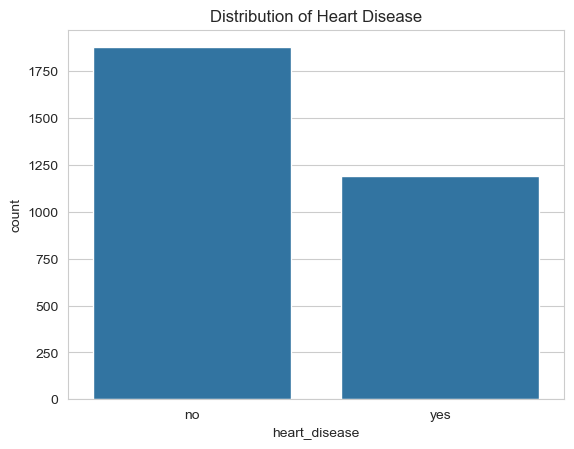

In [45]:
sns.countplot(x="heart_disease", data=df)
plt.title("Distribution of Heart Disease")
plt.show()

Most patients in the dataset do not have heart disease, indicating a class imbalance.

### 4.3. Continuous Variables

In [46]:
df[cont_cols].describe()

,age,trestbps,chol,thalach,oldpeak,bmi
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,145.306289,347.219941,135.157380,3.189052,27.496839
std,13.70752,31.602321,146.853319,43.353197,1.802815,7.281731
min,29.00000,90.000000,100.000000,60.000000,0.000000,15.000000
25%,41.00000,118.000000,215.000000,98.000000,1.600000,21.300000
50%,53.00000,146.000000,350.000000,135.000000,3.200000,27.400000
75%,64.00000,172.000000,475.000000,172.000000,4.700000,33.900000
max,76.00000,200.000000,600.000000,210.000000,6.200000,40.000000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'bmi'}>]], dtype=object)

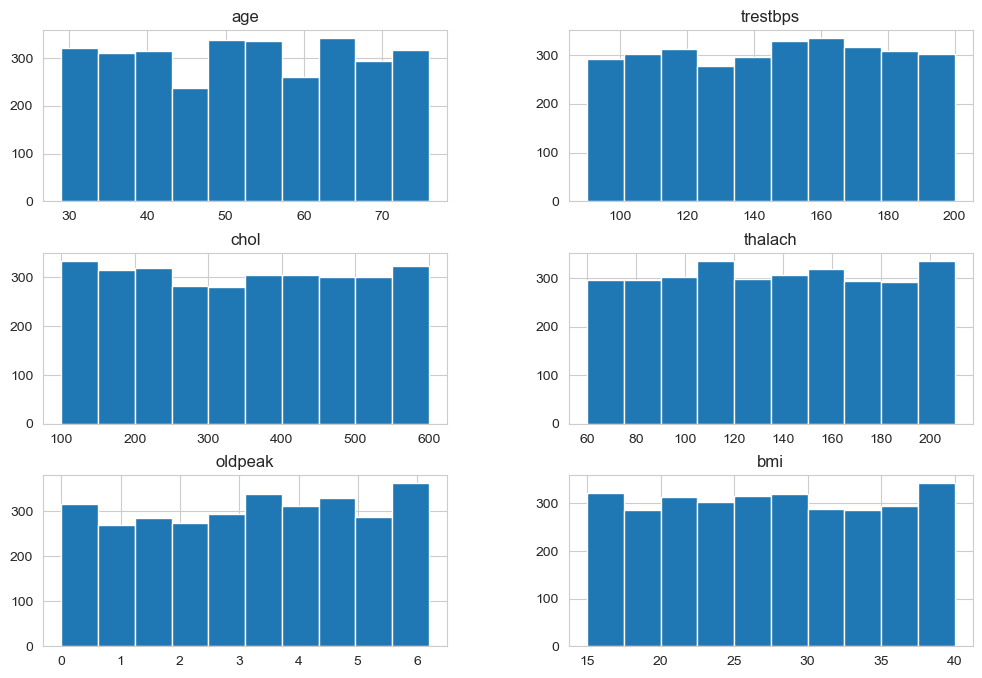

In [47]:
df[cont_cols].hist(figsize=(12,8))

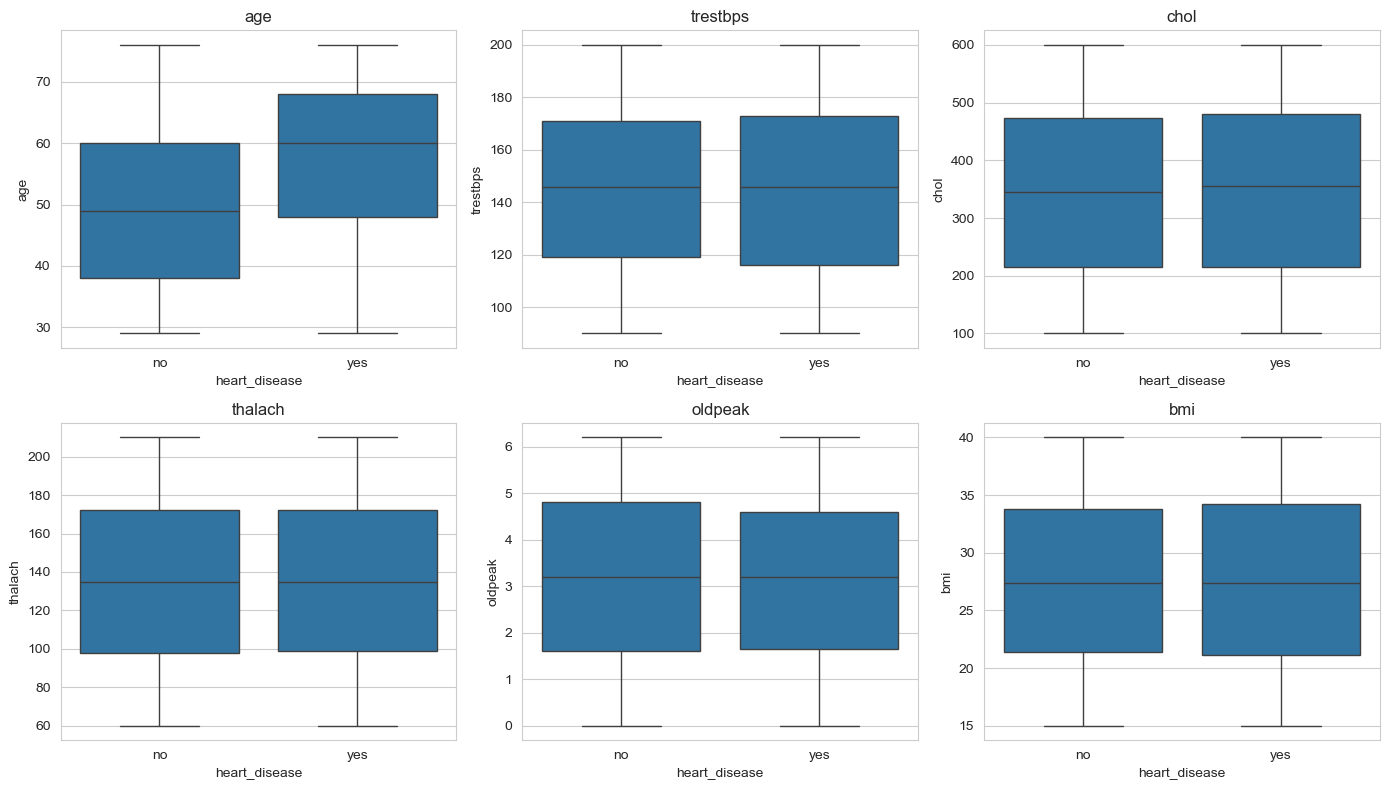

In [48]:
fig, axes = plt.subplots(2,3, figsize=(14,8))
axes = axes.flatten()

for ax, col in zip(axes, cont_cols):
    sns.boxplot(x="heart_disease", y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Age appears higher among patients with heart disease, suggesting a potential association.

In [49]:
df.groupby("heart_disease", observed=True)["age"].median()

heart_disease
no     49.0
yes    60.0
Name: age, dtype: float64

Patients diagnosed with heart disease tend to be older.

### 4.4. Categorical Variables

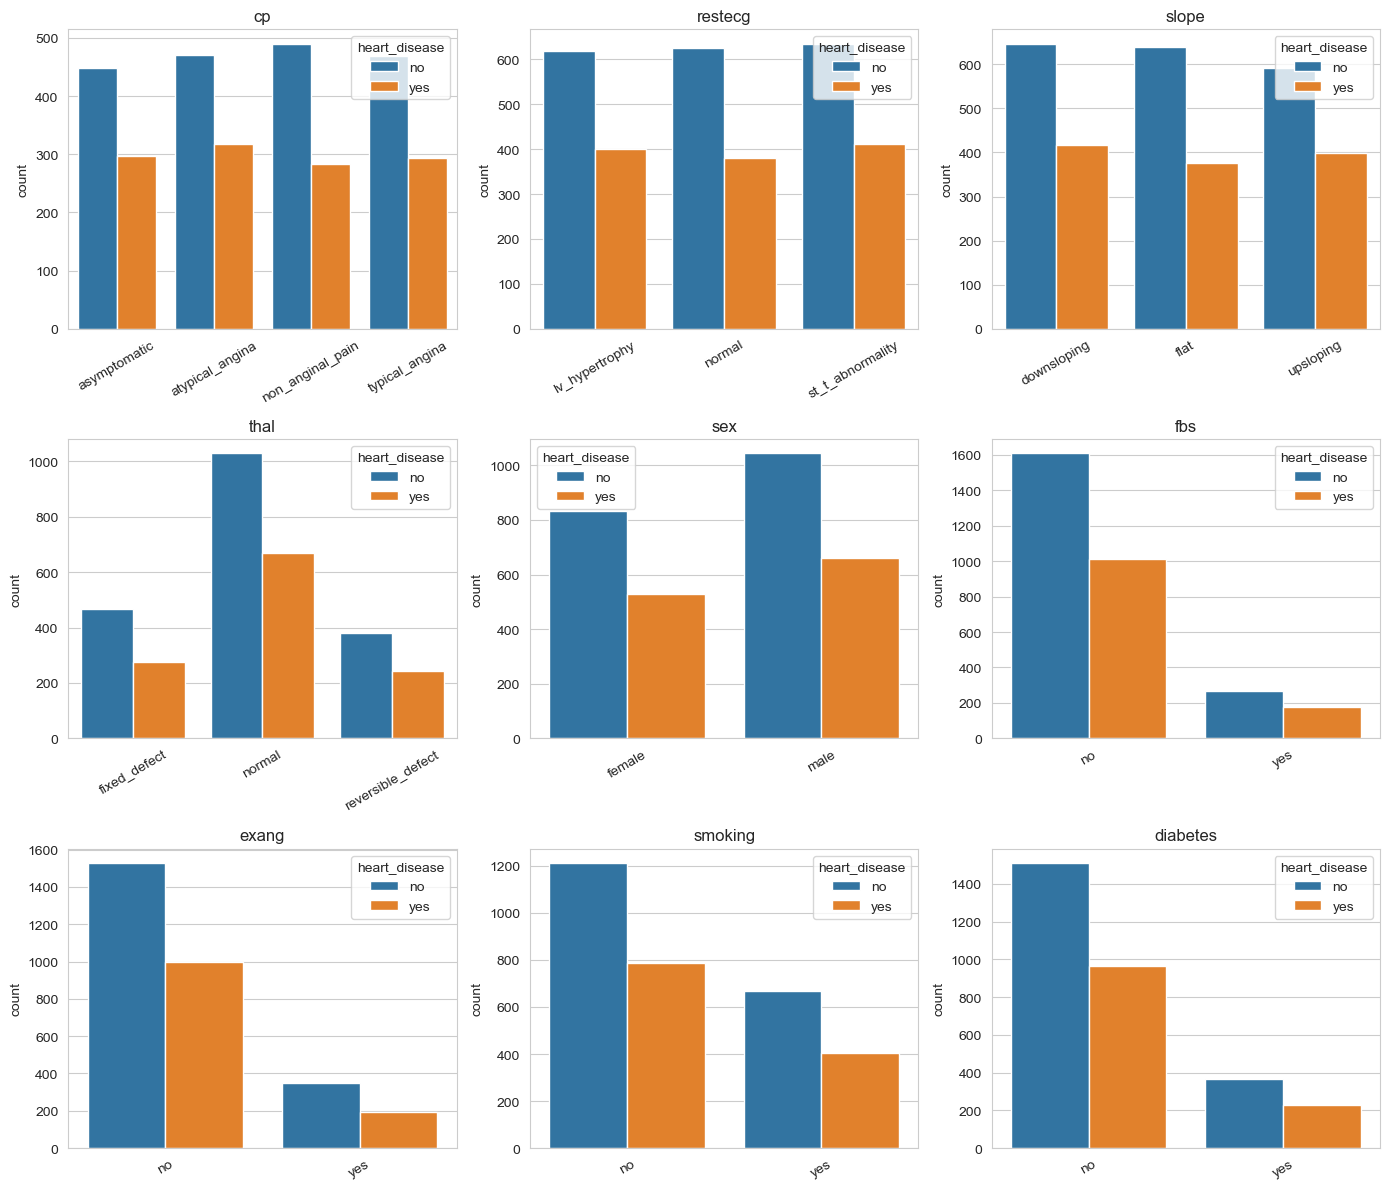

In [52]:
import math 

ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue="heart_disease", data=df, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [53]:
for col in cat_cols:
    print(df[col].value_counts())

cp
atypical_angina     788
non_anginal_pain    773
typical_angina      762
asymptomatic        746
Name: count, dtype: int64
restecg
st_t_abnormality    1046
lv_hypertrophy      1018
normal              1005
Name: count, dtype: int64
slope
downsloping    1063
flat           1016
upsloping       990
Name: count, dtype: int64
thal
normal               1698
fixed_defect          744
reversible_defect     627
Name: count, dtype: int64
sex
male      1705
female    1364
Name: count, dtype: int64
fbs
no     2622
yes     447
Name: count, dtype: int64
exang
no     2528
yes     541
Name: count, dtype: int64
smoking
no     1998
yes    1071
Name: count, dtype: int64
diabetes
no     2474
yes     595
Name: count, dtype: int64


To explore relationships between categorical variables and heart disease,
we calculate row percentages using cross-tabulation:

In [54]:
for col in cat_cols:
    print(f"\n=== {col} vs heart_disease (row %) ===")
    print(pd.crosstab(df[col], df["heart_disease"], normalize="index"))


=== cp vs heart_disease (row %) ===
heart_disease           no       yes
cp                                  
asymptomatic      0.601877  0.398123
atypical_angina   0.597716  0.402284
non_anginal_pain  0.633894  0.366106
typical_angina    0.614173  0.385827

=== restecg vs heart_disease (row %) ===
heart_disease           no       yes
restecg                             
lv_hypertrophy    0.607073  0.392927
normal            0.621891  0.378109
st_t_abnormality  0.607075  0.392925

=== slope vs heart_disease (row %) ===
heart_disease        no       yes
slope                            
downsloping    0.608655  0.391345
flat           0.629921  0.370079
upsloping      0.596970  0.403030

=== thal vs heart_disease (row %) ===
heart_disease            no       yes
thal                                 
fixed_defect       0.627688  0.372312
normal             0.606007  0.393993
reversible_defect  0.609250  0.390750

=== sex vs heart_disease (row %) ===
heart_disease        no       yes
sex

### 4.5. Correlation Analysis

In [55]:
df[cont_cols].corr()

,age,trestbps,chol,thalach,oldpeak,bmi,ca
age,1.000000,0.035303,0.001722,-0.023883,0.033059,-0.029525,0.006783
trestbps,0.035303,1.000000,-0.005646,-0.009357,0.025071,-0.000278,0.007463
chol,0.001722,-0.005646,1.000000,0.051841,-0.016972,-0.015417,-0.005258
thalach,-0.023883,-0.009357,0.051841,1.000000,-0.030678,-0.001801,0.002795
oldpeak,0.033059,0.025071,-0.016972,-0.030678,1.000000,0.008510,-0.003620
bmi,-0.029525,-0.000278,-0.015417,-0.001801,0.008510,1.000000,-0.019418
ca,0.006783,0.007463,-0.005258,0.002795,-0.003620,-0.019418,1.000000


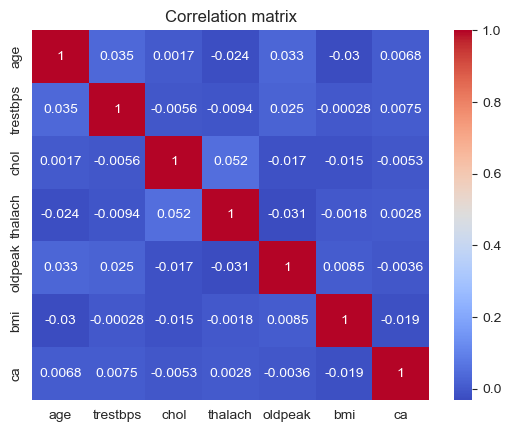

In [56]:
corr = df[cont_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

Correlation analysis shows very weak relationships between all numerical variables. Correlation coefficients are close to zero, indicating the absence of strong linear relationships. This is consistent with the synthetic nature of the dataset.

## 5. Statistical Analysis

We perform statistical tests to evaluate whether observed differences between groups are statistically significant.

### 5.1. Age vs Heart Disease

In [57]:
from scipy.stats import mannwhitneyu

g0 = df.loc[df["heart_disease"]=="no", "age"]
g1 = df.loc[df["heart_disease"]=="yes", "age"]
    
stat, p = mannwhitneyu(g0, g1)
print("Age vs heart disease p-value:", p)

Age vs heart disease p-value: 5.693546619284157e-57


The Mann–Whitney U test shows a significant difference in age between patients with and without heart disease (p < 0.001), suggesting that age may be associated with heart disease risk.

### 5.2. Cholesterol vs Heart Disease

In [58]:
g0 = df.loc[df["heart_disease"]=="no", "chol"]
g1 = df.loc[df["heart_disease"]=="yes", "chol"]
    
stat, p = mannwhitneyu(g0, g1)
print(col, p)

diabetes 0.40220389254816424


The Mann-Whitney U test indicates no significant difference in cholesterol levels between the two groups.

### 5.3. Lifestyle Factors vs Heart Disease

In [59]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["smoking"], df["heart_disease"])

chi2, p, dof, exp = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.6194532329123282
p-value: 0.43125054059060886


The chi-square test suggests no significant association between smoking status and heart disease in this dataset.

In [60]:
table = pd.crosstab(df["diabetes"], df["heart_disease"])

chi2, p, dof, exp = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.1017413831880844
p-value: 0.7497498298399463


The chi-square test suggests no significant association between diabetes status and heart disease in this dataset.

## 6. Summary

- Patients with heart disease are older on average.
- Cholesterol and blood pressure do not differ substantially between groups.
- Lifestyle variables such as smoking and diabetes do not show strong patterns in this dataset.
- Correlations between numerical variables are generally weak.